In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Decision Tree Algorithm - Complete Example
### Step 1: Load the Data

In [2]:
# Load dataset (using Iris dataset as example)
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['target_name'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nDataset info:")
print(df.info())

Dataset loaded successfully!
Dataset shape: (150, 6)

First few rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal 

### Step 2: Data Cleanup

In [3]:
# Data Cleanup
print("Checking for missing values:")
print(df.isnull().sum())

print(f"\nBasic statistics:")
print(df.describe())

# Remove duplicates if any
df_cleaned = df.drop_duplicates()
print(f"\nDuplicates removed. New shape: {df_cleaned.shape}")

# Check for outliers using IQR method
def remove_outliers(data, columns):
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
    return data

# Apply outlier removal (optional for this dataset)
feature_columns = iris.feature_names
df_cleaned = remove_outliers(df_cleaned, feature_columns)
print(f"After outlier removal, shape: {df_cleaned.shape}")

print("\nData cleanup complete!")

Checking for missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
target_name          0
dtype: int64

Basic statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000  

### Step 3: Exploratory Data Analysis (EDA)

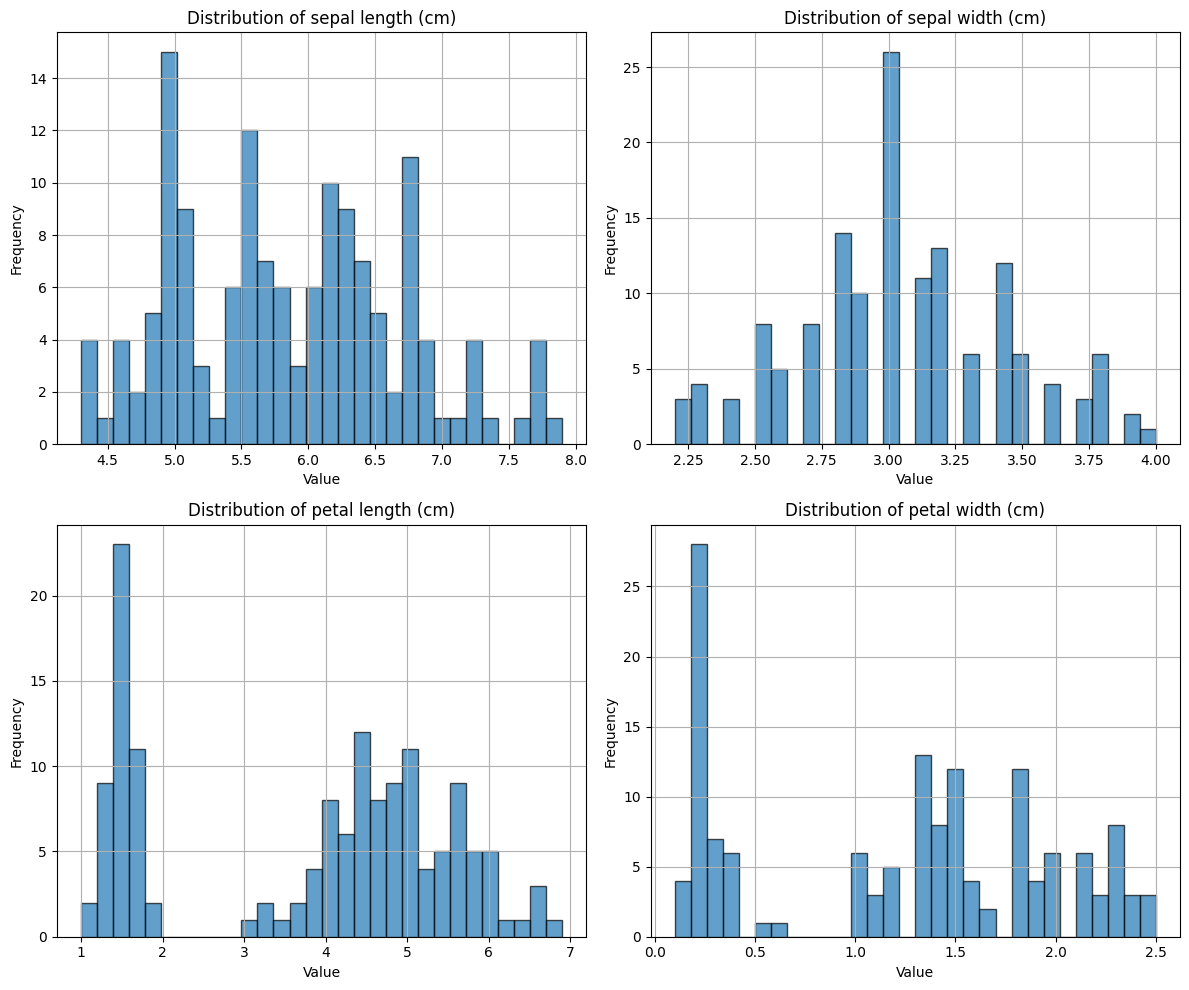

Target variable distribution:
target_name
versicolor    49
virginica     49
setosa        47
Name: count, dtype: int64


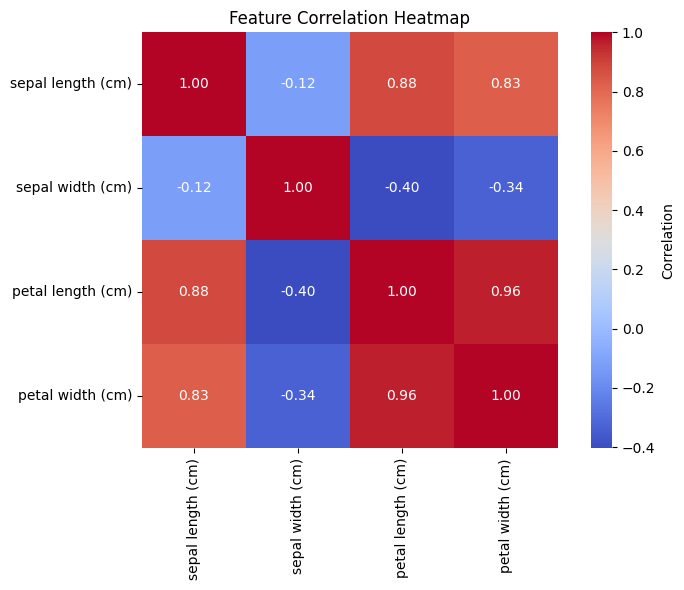

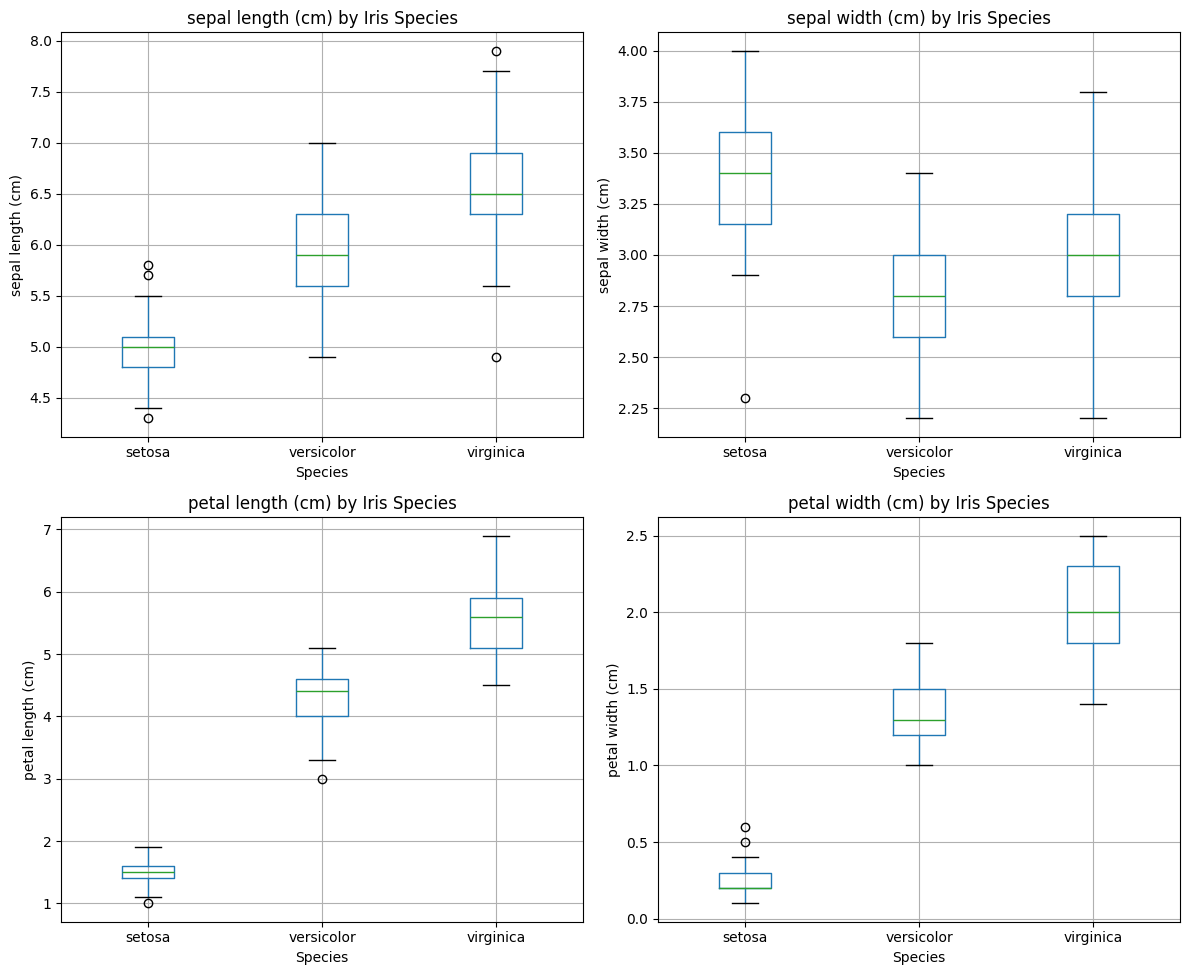


EDA complete!


In [4]:
# Exploratory Data Analysis
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Distribution of features
for idx, col in enumerate(feature_columns):
    ax = axes[idx // 2, idx % 2]
    df_cleaned[col].hist(bins=30, ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Target variable distribution
print("Target variable distribution:")
print(df_cleaned['target_name'].value_counts())

# Correlation heatmap
plt.figure(figsize=(8, 6))
numeric_df = df_cleaned[feature_columns]
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            square=True, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Box plots by target
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, col in enumerate(feature_columns):
    ax = axes[idx // 2, idx % 2]
    df_cleaned.boxplot(column=col, by='target_name', ax=ax)
    ax.set_title(f'{col} by Iris Species')
    ax.set_xlabel('Species')
    ax.set_ylabel(col)

plt.suptitle('')
plt.tight_layout()
plt.show()

print("\nEDA complete!")

### Step 4: Train-Test Split

In [5]:
# Prepare features and target
X = df_cleaned[feature_columns]
y = df_cleaned['target']

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"Total samples: {len(X)}")
print(f"\nClass distribution in training set:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nClass distribution in testing set:")
print(pd.Series(y_test).value_counts().sort_index())

Training set size: 116
Testing set size: 29
Total samples: 145

Class distribution in training set:
target
0    38
1    39
2    39
Name: count, dtype: int64

Class distribution in testing set:
target
0     9
1    10
2    10
Name: count, dtype: int64


### Step 5: Build and Train Decision Tree Model

Decision Tree Model trained successfully!

Tree depth: 5
Number of leaves: 7


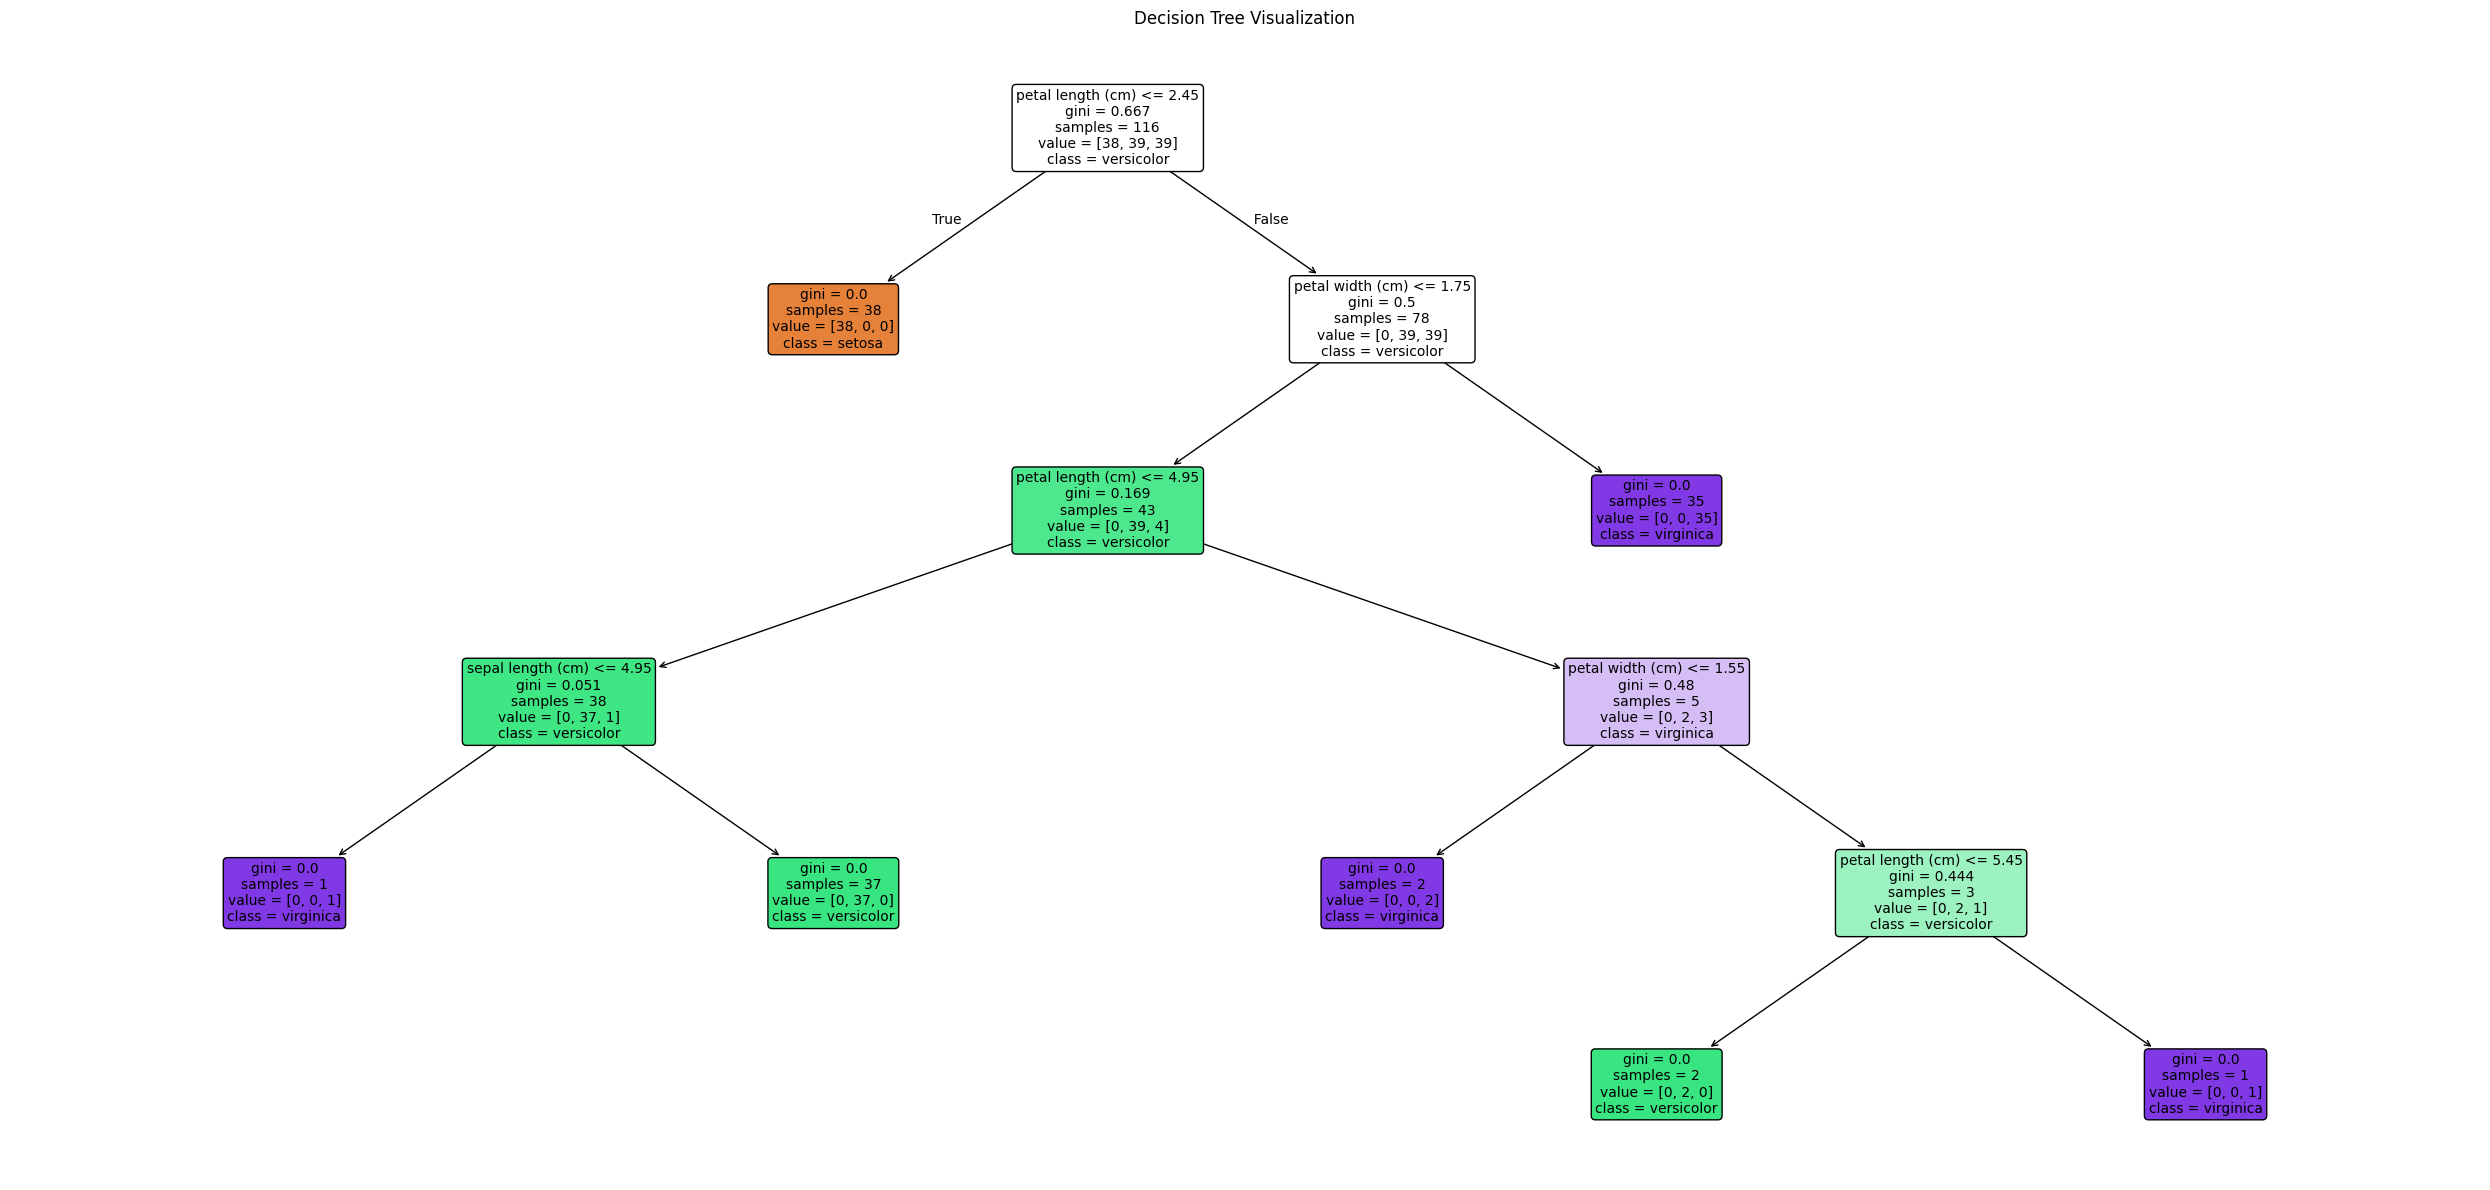


Feature Importance:
             feature  importance
2  petal length (cm)    0.550507
3   petal width (cm)    0.424310
0  sepal length (cm)    0.025183
1   sepal width (cm)    0.000000


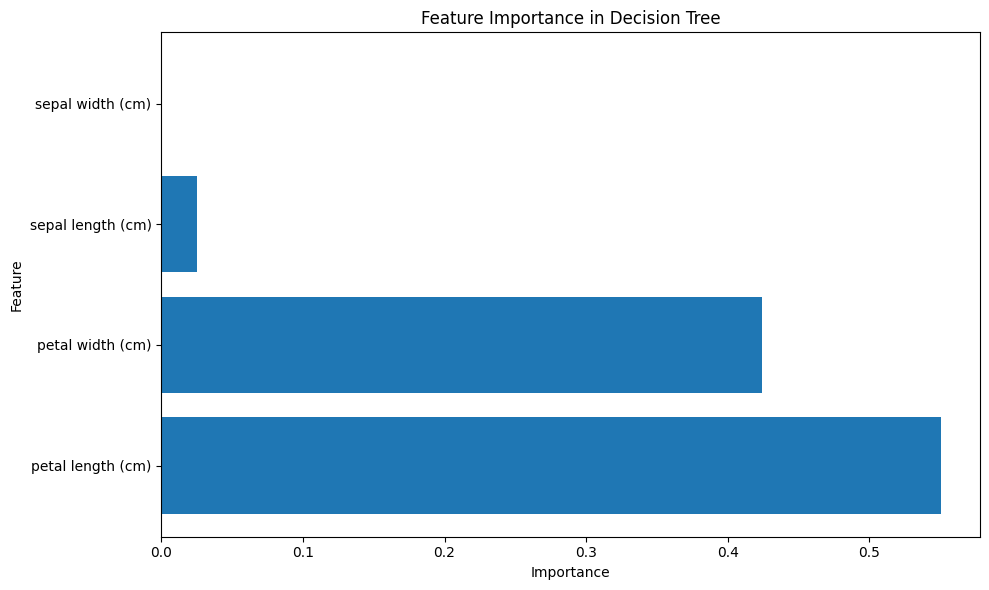

In [6]:
# Create and train Decision Tree model
dt_classifier = DecisionTreeClassifier(
    max_depth=5,              # Limit tree depth to avoid overfitting
    min_samples_split=2,      # Minimum samples required to split
    min_samples_leaf=1,       # Minimum samples required at leaf node
    random_state=42,
    criterion='gini'          # Use Gini impurity criterion
)

# Fit the model on training data
dt_classifier.fit(X_train, y_train)

print("Decision Tree Model trained successfully!")
print(f"\nTree depth: {dt_classifier.get_depth()}")
print(f"Number of leaves: {dt_classifier.get_n_leaves()}")

# Visualize the decision tree
plt.figure(figsize=(25, 12))
plot_tree(dt_classifier, 
          feature_names=feature_columns,
          class_names=['setosa', 'versicolor', 'virginica'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Visualization')
plt.tight_layout()
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': dt_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Decision Tree')
plt.tight_layout()
plt.show()

### Step 6: Make Predictions on Test Set

In [7]:
# Make predictions on test set
y_pred_test = dt_classifier.predict(X_test)

# Get probability predictions
y_pred_proba_test = dt_classifier.predict_proba(X_test)

# Make predictions on training set
y_pred_train = dt_classifier.predict(X_train)

print("Predictions on test set:")
print(f"First 10 predictions: {y_pred_test[:10]}")
print(f"First 10 actual values: {y_test.values[:10]}")

print("\nPrediction probabilities (first 5 samples):")
print(y_pred_proba_test[:5])

# Create a comparison dataframe
comparison_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_test[:10],
    'Setosa_Prob': y_pred_proba_test[:10, 0],
    'Versicolor_Prob': y_pred_proba_test[:10, 1],
    'Virginica_Prob': y_pred_proba_test[:10, 2]
})

print("\nComparison of first 10 predictions:")
print(comparison_df)

Predictions on test set:
First 10 predictions: [1 1 2 0 2 1 2 2 2 0]
First 10 actual values: [1 1 2 0 2 1 2 2 1 0]

Prediction probabilities (first 5 samples):
[[0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]

Comparison of first 10 predictions:
   Actual  Predicted  Setosa_Prob  Versicolor_Prob  Virginica_Prob
0       1          1          0.0              1.0             0.0
1       1          1          0.0              1.0             0.0
2       2          2          0.0              0.0             1.0
3       0          0          1.0              0.0             0.0
4       2          2          0.0              0.0             1.0
5       1          1          0.0              1.0             0.0
6       2          2          0.0              0.0             1.0
7       2          2          0.0              0.0             1.0
8       1          2          0.0              0.0             1.0
9       0          0          1.0              0.0             0.0


### Step 7: Model Evaluation - Metrics and Error Functions

MODEL EVALUATION METRICS

TRAINING SET METRICS:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1 Score:  1.0000

TEST SET METRICS:
  Accuracy:  0.9310
  Precision: 0.9425
  Recall:    0.9310
  F1 Score:  0.9303

DETAILED CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         9
  versicolor       1.00      0.80      0.89        10
   virginica       0.83      1.00      0.91        10

    accuracy                           0.93        29
   macro avg       0.94      0.93      0.93        29
weighted avg       0.94      0.93      0.93        29


Confusion Matrix (Test Set):
[[ 9  0  0]
 [ 0  8  2]
 [ 0  0 10]]


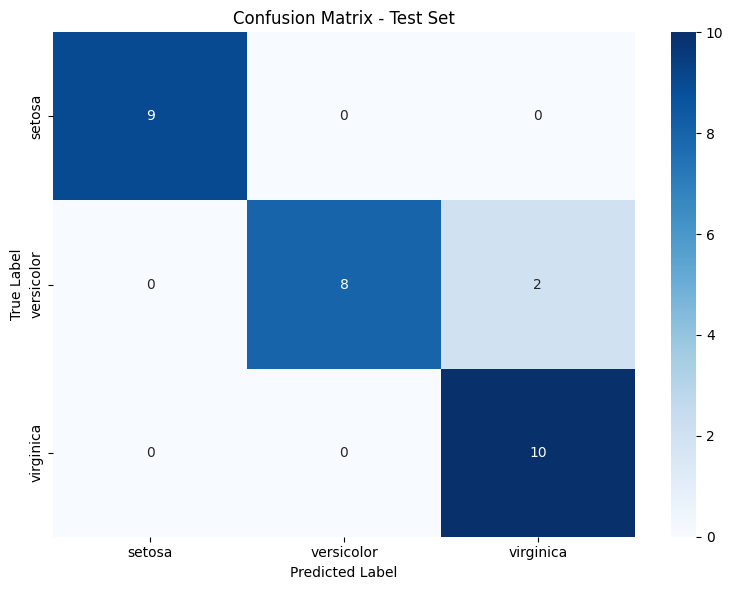

In [ ]:
,# Calculate evaluation metrics for test set
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, average='weighted')
recall_test = recall_score(y_test, y_pred_test, average='weighted')
f1_test = f1_score(y_test, y_pred_test, average='weighted')

# Calculate metrics for training set (to check for overfitting)
accuracy_train = accuracy_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train, average='weighted')
recall_train = recall_score(y_train, y_pred_train, average='weighted')
f1_train = f1_score(y_train, y_pred_train, average='weighted')

print("="*60)
print("MODEL EVALUATION METRICS")
print("="*60)
print("\nTRAINING SET METRICS:")
print(f"  Accuracy:  {accuracy_train:.4f}")
print(f"  Precision: {precision_train:.4f}")
print(f"  Recall:    {recall_train:.4f}")
print(f"  F1 Score:  {f1_train:.4f}")

print("\nTEST SET METRICS:")
print(f"  Accuracy:  {accuracy_test:.4f}")
print(f"  Precision: {precision_test:.4f}")
print(f"  Recall:    {recall_test:.4f}")
print(f"  F1 Score:  {f1_test:.4f}")

print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT (Test Set)")
print("="*60)
print(classification_report(y_test, y_pred_test, 
                          target_names=['setosa', 'versicolor', 'virginica']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
print("\nConfusion Matrix (Test Set):")
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

### Step 8: Error Functions and Additional Metrics

In [9]:
# Define error functions
def mean_absolute_error(y_true, y_pred):
    """Calculate Mean Absolute Error"""
    return np.mean(np.abs(y_true - y_pred))

def mean_squared_error(y_true, y_pred):
    """Calculate Mean Squared Error"""
    return np.mean((y_true - y_pred) ** 2)

def root_mean_squared_error(y_true, y_pred):
    """Calculate Root Mean Squared Error"""
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def misclassification_rate(y_true, y_pred):
    """Calculate Misclassification Rate (Error Rate)"""
    return 1 - accuracy_score(y_true, y_pred)

def specificity(y_true, y_pred, class_label):
    """Calculate Specificity for a specific class"""
    # True negatives / (True negatives + False positives)
    binary_true = (y_true != class_label).astype(int)
    binary_pred = (y_pred != class_label).astype(int)
    tn = np.sum((binary_true == 1) & (binary_pred == 1))
    fp = np.sum((binary_true == 1) & (binary_pred == 0))
    return tn / (tn + fp) if (tn + fp) > 0 else 0

# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = root_mean_squared_error(y_test, y_pred_test)
error_rate = misclassification_rate(y_test, y_pred_test)

print("="*60)
print("ERROR FUNCTIONS")
print("="*60)
print(f"Mean Absolute Error (MAE):       {mae:.4f}")
print(f"Mean Squared Error (MSE):        {mse:.4f}")
print(f"Root Mean Squared Error (RMSE):  {rmse:.4f}")
print(f"Misclassification Rate (Error):  {error_rate:.4f}")

print("\n" + "="*60)
print("PER-CLASS METRICS")
print("="*60)
for class_idx, class_name in enumerate(['setosa', 'versicolor', 'virginica']):
    y_test_binary = (y_test == class_idx).astype(int)
    y_pred_binary = (y_pred_test == class_idx).astype(int)
    
    precision = precision_score(y_test_binary, y_pred_binary, zero_division=0)
    recall = recall_score(y_test_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_test_binary, y_pred_binary, zero_division=0)
    spec = specificity(y_test, y_pred_test, class_idx)
    
    print(f"\n{class_name.upper()}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  Specificity: {spec:.4f}")

# Create metrics summary table
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'MAE', 'MSE', 'RMSE', 'Error Rate'],
    'Train Set': [accuracy_train, precision_train, recall_train, f1_train, 
                  mean_absolute_error(y_train, y_pred_train),
                  mean_squared_error(y_train, y_pred_train),
                  root_mean_squared_error(y_train, y_pred_train),
                  misclassification_rate(y_train, y_pred_train)],
    'Test Set': [accuracy_test, precision_test, recall_test, f1_test, 
                 mae, mse, rmse, error_rate]
})

print("\n" + "="*60)
print("METRICS COMPARISON")
print("="*60)
print(metrics_summary.to_string(index=False))

ERROR FUNCTIONS
Mean Absolute Error (MAE):       0.0690
Mean Squared Error (MSE):        0.0690
Root Mean Squared Error (RMSE):  0.2626
Misclassification Rate (Error):  0.0690

PER-CLASS METRICS

SETOSA:
  Precision: 1.0000
  Recall:    1.0000
  F1 Score:  1.0000
  Specificity: 1.0000

VERSICOLOR:
  Precision: 1.0000
  Recall:    0.8000
  F1 Score:  0.8889
  Specificity: 1.0000

VIRGINICA:
  Precision: 0.8333
  Recall:    1.0000
  F1 Score:  0.9091
  Specificity: 0.8947

METRICS COMPARISON
    Metric  Train Set  Test Set
  Accuracy        1.0  0.931034
 Precision        1.0  0.942529
    Recall        1.0  0.931034
  F1 Score        1.0  0.930338
       MAE        0.0  0.068966
       MSE        0.0  0.068966
      RMSE        0.0  0.262613
Error Rate        0.0  0.068966


### Step 9: Test Model with External/Custom Data

PREDICTIONS ON EXTERNAL DATA

External Data Input:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                6.5               3.0                5.5               1.8
2                7.2               3.2                6.0               2.0

Prediction Results:
  Sample Predicted Class  Setosa Prob  Versicolor Prob  Virginica Prob  Confidence
Sample 1          setosa          1.0              0.0             0.0         1.0
Sample 2       virginica          0.0              0.0             1.0         1.0
Sample 3       virginica          0.0              0.0             1.0         1.0


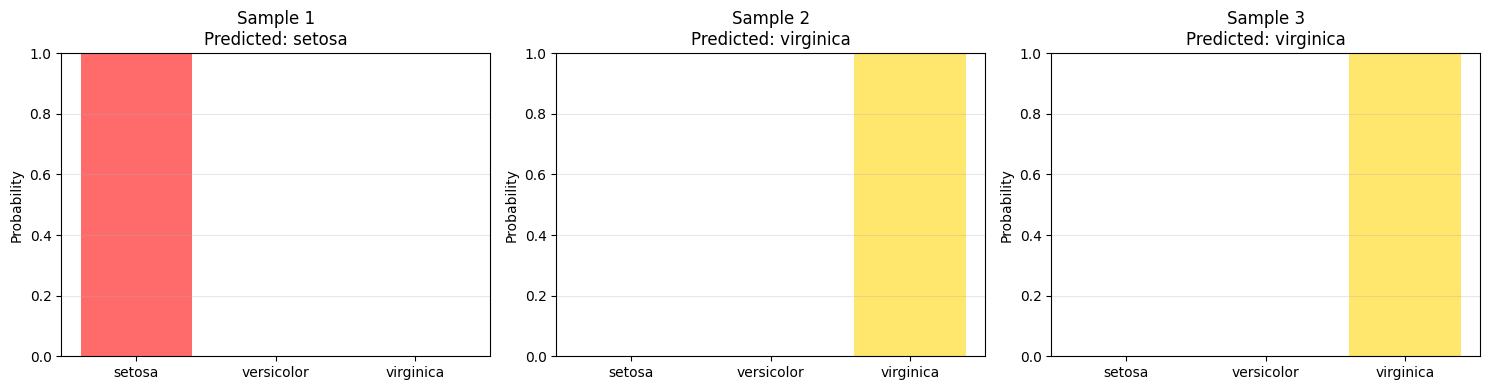


Model successfully tested on external data!


In [10]:
# Test with custom/external data
external_data = pd.DataFrame({
    'sepal length (cm)': [5.1, 6.5, 7.2],
    'sepal width (cm)': [3.5, 3.0, 3.2],
    'petal length (cm)': [1.4, 5.5, 6.0],
    'petal width (cm)': [0.2, 1.8, 2.0]
})

print("="*60)
print("PREDICTIONS ON EXTERNAL DATA")
print("="*60)
print("\nExternal Data Input:")
print(external_data)

# Make predictions
external_predictions = dt_classifier.predict(external_data)
external_predictions_proba = dt_classifier.predict_proba(external_data)

species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

# Create detailed results
external_results = pd.DataFrame({
    'Sample': [f'Sample {i+1}' for i in range(len(external_data))],
    'Predicted Class': [species_map[pred] for pred in external_predictions],
    'Setosa Prob': external_predictions_proba[:, 0],
    'Versicolor Prob': external_predictions_proba[:, 1],
    'Virginica Prob': external_predictions_proba[:, 2],
    'Confidence': np.max(external_predictions_proba, axis=1)
})

print("\nPrediction Results:")
print(external_results.to_string(index=False))

# Visualize predictions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (sample_idx, row) in enumerate(external_results.iterrows()):
    probs = [row['Setosa Prob'], row['Versicolor Prob'], row['Virginica Prob']]
    colors = ['#FF6B6B', '#4ECDC4', '#FFE66D']
    axes[idx].bar(['setosa', 'versicolor', 'virginica'], probs, color=colors)
    axes[idx].set_title(f"Sample {sample_idx + 1}\nPredicted: {row['Predicted Class']}")
    axes[idx].set_ylabel('Probability')
    axes[idx].set_ylim([0, 1])
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nModel successfully tested on external data!")

### Step 10: Model Summary and Key Insights

In [11]:
print("="*70)
print("DECISION TREE MODEL SUMMARY & KEY INSIGHTS")
print("="*70)

print(f"\n📊 DATA SUMMARY:")
print(f"  • Total samples: {len(df_cleaned)}")
print(f"  • Training samples: {len(X_train)}")
print(f"  • Test samples: {len(X_test)}")
print(f"  • Number of features: {len(feature_columns)}")
print(f"  • Classes: 3 (setosa, versicolor, virginica)")

print(f"\n🌳 MODEL PARAMETERS:")
print(f"  • Max depth: {dt_classifier.max_depth}")
print(f"  • Tree depth: {dt_classifier.get_depth()}")
print(f"  • Number of leaves: {dt_classifier.get_n_leaves()}")
print(f"  • Criterion: {dt_classifier.criterion}")
print(f"  • Min samples split: {dt_classifier.min_samples_split}")

print(f"\n📈 PERFORMANCE METRICS (Test Set):")
print(f"  • Accuracy:  {accuracy_test:.4f} ({accuracy_test*100:.2f}%)")
print(f"  • Precision: {precision_test:.4f}")
print(f"  • Recall:    {recall_test:.4f}")
print(f"  • F1 Score:  {f1_test:.4f}")

print(f"\n❌ ERROR METRICS (Test Set):")
print(f"  • Error Rate: {error_rate:.4f} ({error_rate*100:.2f}%)")
print(f"  • MAE:  {mae:.4f}")
print(f"  • MSE:  {mse:.4f}")
print(f"  • RMSE: {rmse:.4f}")

print(f"\n⭐ TOP 3 IMPORTANT FEATURES:")
for idx, row in feature_importance.head(3).iterrows():
    print(f"  {idx+1}. {row['feature']}: {row['importance']:.4f}")

print(f"\n✅ OVERFITTING CHECK:")
overfit_gap = accuracy_train - accuracy_test
print(f"  • Train Accuracy: {accuracy_train:.4f}")
print(f"  • Test Accuracy:  {accuracy_test:.4f}")
print(f"  • Gap: {overfit_gap:.4f}")
if overfit_gap > 0.1:
    print(f"  ⚠️  Possible overfitting detected!")
else:
    print(f"  ✓ Model is well-generalized")

print("\n" + "="*70)
print("✓ Decision Tree model training and evaluation completed successfully!")
print("="*70)

DECISION TREE MODEL SUMMARY & KEY INSIGHTS

📊 DATA SUMMARY:
  • Total samples: 145
  • Training samples: 116
  • Test samples: 29
  • Number of features: 4
  • Classes: 3 (setosa, versicolor, virginica)

🌳 MODEL PARAMETERS:
  • Max depth: 5
  • Tree depth: 5
  • Number of leaves: 7
  • Criterion: gini
  • Min samples split: 2

📈 PERFORMANCE METRICS (Test Set):
  • Accuracy:  0.9310 (93.10%)
  • Precision: 0.9425
  • Recall:    0.9310
  • F1 Score:  0.9303

❌ ERROR METRICS (Test Set):
  • Error Rate: 0.0690 (6.90%)
  • MAE:  0.0690
  • MSE:  0.0690
  • RMSE: 0.2626

⭐ TOP 3 IMPORTANT FEATURES:
  3. petal length (cm): 0.5505
  4. petal width (cm): 0.4243
  1. sepal length (cm): 0.0252

✅ OVERFITTING CHECK:
  • Train Accuracy: 1.0000
  • Test Accuracy:  0.9310
  • Gap: 0.0690
  ✓ Model is well-generalized

✓ Decision Tree model training and evaluation completed successfully!
